# 05. Tensor-network validation & quench error budget

把三个相关的 TN / 基态 / 误差研究合并到一处。三个 Part 各自**自包含**(可单独从本 Part 第一格起跑)。

- **Part A — finite-PEPS 收敛**:`backend="peps"` 三能级 `01r` 是否对 exact 收敛(扫 `dt`/`chi`,BP vs CTM measurement)。
- **Part B — 2D TFIM 临界场 `g_c`**:exact / MPS-DMRG / PEPS(YASTN)算基态能量;关联比用 MPS + exact 交叉读 `g_c`(QMC 参考 3.04438)。直接调底层 TN backend 的 `find_ground_state`(基态没有 `rg.simulate` 公共入口)。
- **Part C — quench error budget 扫描**:`a / Delta_e / v` 三参数最小化绝热制备误差(1r 相干 + 解析退相干)。

> 合并自 `01r_yastn_peps_convergence` + `01r_tfim_critical_field` + `error_budget_sweep`。

In [1]:
# Pin BLAS/OpenMP to 1 thread BEFORE importing numpy/scipy/tenpy.
# Small TN tensors (DMRG/TDVP/PEPS) => multi-threaded BLAS oversubscribes
# cores and runs 10-40x SLOWER on a loaded box. This cell must stay first
# and run before any import: the libraries read these variables only once,
# at import time.
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")
print("BLAS/OpenMP threads pinned to", os.environ.get("OMP_NUM_THREADS"))

BLAS/OpenMP threads pinned to 1


## Part A — finite-PEPS 收敛 benchmark

验证 `backend="peps"` 真的作为三能级 `01r` finite PEPS 工作:小 `2x2` 应与 exact 一致,随 `dt`↓ / `chi_max`↑ 向 exact 收敛。

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

import ryd_gate as rg
from ryd_gate import RydbergSystem
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol

plt.rcParams.update({"figure.dpi": 120})

## 1. 构造 01r 二维 lattice 和 time-dependent protocol

物理常数取自 **`our` 参数集**（与 Part C 相同，见 `physical_models.py`）。仿真内部单位 **rad/s + s**；`Omega_R = omega_eff(Delta_e)`，`C6` 与间距 `a = 7 μm` 给出最近邻 blockade `V_nn`。

保持无量纲脉宽 `Omega_R * t_gate = 0.8`（与旧玩具标度相同动力学），`t_eval` 取 `0.2/Omega_R` 的整数倍以便三组 PEPS `dt` 对齐。

N = 4 local_dim = 3 Hilbert dim = 81
interaction pairs = ((0, 1, 46677013.47631478), (0, 2, 46677013.47631478), (1, 3, 46677013.47631478), (2, 3, 46677013.47631478))
Omega_R = 4.99 MHz,  V_nn = 7.43 MHz,  t_gate = 0.128 μs
t_eval (μs) = [0.         0.00318888 0.00637776 0.00956664 0.01275552 0.0159444
 0.01913329 0.02232217 0.02551105 0.02869993 0.03188881 0.03507769
 0.03826657 0.04145545 0.04464433 0.04783321 0.05102209 0.05421098
 0.05739986 0.06058874 0.06377762 0.0669665  0.07015538 0.07334426
 0.07653314 0.07972202 0.0829109  0.08609978 0.08928867 0.09247755
 0.09566643 0.09885531 0.10204419 0.10523307 0.10842195 0.11161083
 0.11479971 0.11798859 0.12117747 0.12436636 0.12755524]


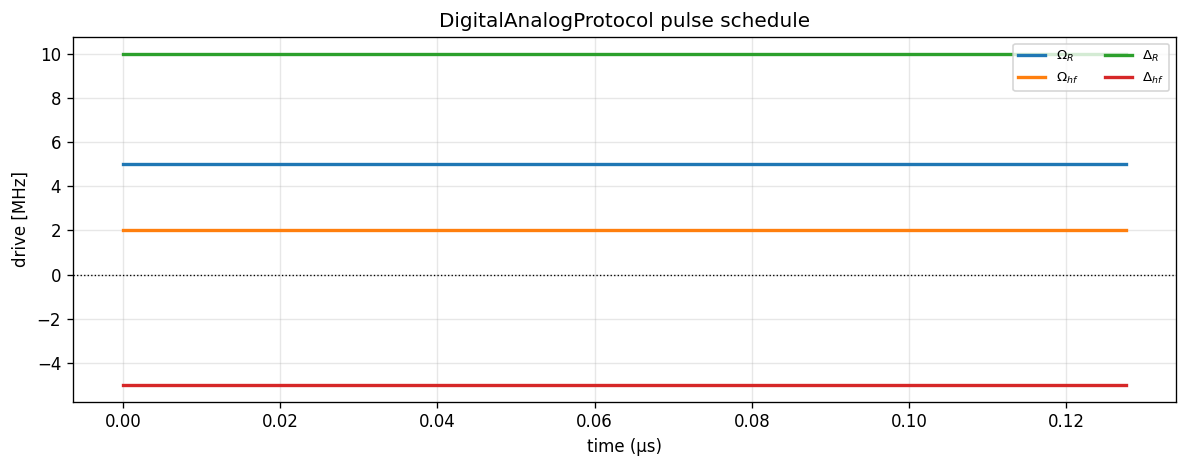

In [8]:
# ====== 'our' 参数集常数 (rad/s; 见 Part C / physical_models.py:128-146) ======
OMEGA_420  = 2 * np.pi * 491e6
OMEGA_1013 = 2 * np.pi * 185e6
C6         = 2 * np.pi * 874e9
DELTA_E_0  = 2 * np.pi * 9.1e9

def omega_eff(delta_e):
    return OMEGA_420 * OMEGA_1013 / (2.0 * delta_e)

Lx, Ly = 2, 2
a_um = 7.0
Omega_R = omega_eff(DELTA_E_0)
Omega_hf = 2 * np.pi * 2.0e6       # |0>↔|1> Rabi，验证三能级 PEPS
Delta_R = 2 * np.pi * 10e6         # Rydberg 失谐 ~10 MHz
Delta_hf = -2 * np.pi * 5e6
V_nn = C6 / a_um**6

# 无量纲脉宽 Omega_R * t_gate = 0.8；t_eval 与 dt_factor=0.2/0.1/0.05 对齐
dt_align = 0.1 / Omega_R
t_gate = 40.0 * dt_align

geom = Register.rectangle(Lx, Ly, spacing_um=a_um)
interaction = InteractionSpec(C6=C6, mode="nn")
protocol = DigitalAnalogProtocol(
    t_gate=t_gate,
    omega_R_fn=lambda t: Omega_R,
    omega_hf_fn=lambda t: Omega_hf,
    delta_R_fn=lambda t: Delta_R,
    delta_hf_fn=lambda t: Delta_hf,
    n_steps=240,
)
system = RydbergSystem.from_lattice(
    geom,
    "01r",
    interaction=interaction,
    protocol=protocol,
)
MHz = 1 / (2 * np.pi * 1e6)
protocol.plot(
    system=system,
    unit_scale=MHz,
    unit_label="MHz",
    time_scale=1e6,
    time_label="time (μs)",
)
initial_state = "all_1"
t_eval = np.arange(41) * dt_align

coords = np.asarray(geom.coords)
x_vals = np.unique(coords[:, 0])
y_vals = np.unique(coords[:, 1])

print("N =", system.N, "local_dim =", system.basis.local_dim, "Hilbert dim =", system.dim)
print("interaction pairs =", system.meta("interaction_pairs"))
print(f"Omega_R = {Omega_R * MHz:.2f} MHz,  V_nn = {V_nn * MHz:.2f} MHz,  t_gate = {t_gate * 1e6:.3f} μs")
print("t_eval (μs) =", t_eval * 1e6)

## 2. Exact baseline

`3^4=81` 维直接演化态矢量,作 PEPS convergence 基准;记录 `n_0/n_1/n_r` 与平均 Rydberg occupation。

exact runtime: 1.540 s
time (μs)   <n_r> exact
  0.000     0.000000
  0.003     0.002479
  0.006     0.009666
  0.010     0.020847
  0.013     0.034930
  0.016     0.050586
  0.019     0.066399
  0.022     0.081023
  0.026     0.093307
  0.029     0.102390
  0.032     0.107744
  0.035     0.109186
  0.038     0.106848
  0.041     0.101127
  0.045     0.092630
  0.048     0.082105
  0.051     0.070397
  0.054     0.058387
  0.057     0.046957
  0.061     0.036947
  0.064     0.029106
  0.067     0.024046
  0.070     0.022185
  0.073     0.023699
  0.077     0.028475
  0.080     0.036095
  0.083     0.045845
  0.086     0.056764
  0.089     0.067728
  0.092     0.077564
  0.096     0.085182
  0.099     0.089705
  0.102     0.090582
  0.105     0.087660
  0.108     0.081212
  0.112     0.071908
  0.115     0.060740
  0.118     0.048897
  0.121     0.037629
  0.124     0.028101
  0.128     0.021267


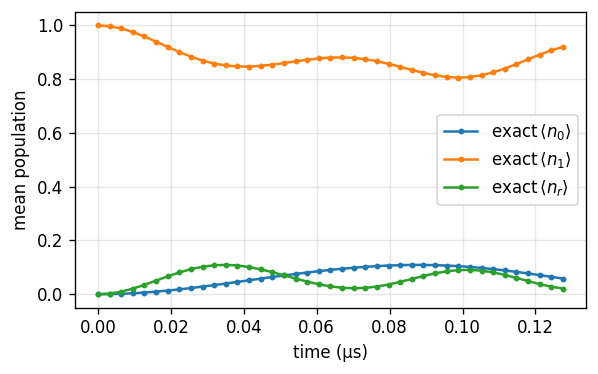

In [11]:
tic = time.perf_counter()
exact_res = rg.simulate(system, [], initial_state, backend="exact_dense", t_eval=t_eval)
exact_time = time.perf_counter() - tic

exact_n0 = np.asarray([
    [system.expectation(f"n_0_{i}", psi) for i in range(system.N)]
    for psi in exact_res.states
])
exact_n1 = np.asarray([
    [system.expectation(f"n_1_{i}", psi) for i in range(system.N)]
    for psi in exact_res.states
])
exact_nr = np.asarray([
    [system.expectation(f"n_r_{i}", psi) for i in range(system.N)]
    for psi in exact_res.states
])
exact_n_mean = exact_nr.mean(axis=1)

print(f"exact runtime: {exact_time:.3f} s")
print("time (μs)   <n_r> exact")
for t, val in zip(t_eval, exact_n_mean):
    print(f"{t * 1e6:7.3f}   {val:10.6f}")

fig, ax = plt.subplots(figsize=(5.5, 3.2))
t_us = t_eval * 1e6
ms = 2.5
ax.plot(t_us, exact_n0.mean(axis=1), "o-", ms=ms, label=r"$\mathrm{exact}\,\langle n_0 \rangle$")
ax.plot(t_us, exact_n1.mean(axis=1), "o-", ms=ms, label=r"$\mathrm{exact}\,\langle n_1 \rangle$")
ax.plot(t_us, exact_n_mean, "o-", ms=ms, label=r"$\mathrm{exact}\,\langle n_r \rangle$")
ax.set_xlabel("time (μs)")
ax.set_ylabel("mean population")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 3. PEPS convergence sweep

扫 `dt=0.2/0.1/0.05 /Omega_R`、`chi_max=4/6/8/12`、`update_environment=NTU/CTM`(measurement 用快的 BP)。`dt`↓→Trotter error↓,`chi_max`↑→truncation error↓;不收敛通常表现为 `max_site_error` 不单调或 truncation error 偏大。

In [15]:
# Trotter 离散误差
dt_factors = [0.1, 0.05, 0.01]
# 键维截断误差
chi_values = [4, 6, 8, 12]
# 更新环境
update_envs = ["ntu", "ctm"]

rows = []
peps_results = {}

for update_env in update_envs:
    for chi in chi_values:
        for factor in dt_factors:
            dt = factor / Omega_R
            key = (update_env, chi, factor)
            tic = time.perf_counter()
            try:
                res = rg.simulate(
                    system,
                    [],
                    initial_state,
                    backend="peps",
                    t_eval=t_eval,
                    observables=["n_0", "n_1", "n_r", "n_mean"],
                    backend_options={
                        "chi_max": chi,
                        "dt": dt,
                        "svd_min": 1e-10,
                        "update_environment": update_env,
                        "measurement_environment": "bp",
                        "initialization": "SVD",
                        "max_iter": 30,
                        "tol_iter": 1e-12,
                        "use_cuda": False,
                    },
                )
                runtime = time.perf_counter() - tic
                nr = np.asarray(res.metadata["obs"]["n_r"])
                nmean = np.asarray(res.metadata["obs"]["n_mean"])
                max_mean_error = float(np.max(np.abs(nmean - exact_n_mean)))
                max_site_error = float(np.max(np.abs(nr - exact_nr)))
                max_trunc = float(res.metadata.get("max_truncation_error", np.nan))
                acc_trunc = res.metadata.get("accumulated_truncation_error")
                rows.append({
                    "env": update_env,
                    "chi": chi,
                    "dt_factor": factor,
                    "status": "ok",
                    "time_s": runtime,
                    "max_mean_error": max_mean_error,
                    "max_site_error": max_site_error,
                    "max_truncation_error": max_trunc,
                    "accumulated_truncation_error": acc_trunc,
                })
                peps_results[key] = res
                print(f"ok   env={update_env:3s} chi={chi:2d} dt={factor:.2f}/Omega  "
                      f"time={runtime:7.2f}s site_err={max_site_error:.3e} trunc={max_trunc:.3e}")
            except Exception as exc:
                runtime = time.perf_counter() - tic
                rows.append({
                    "env": update_env,
                    "chi": chi,
                    "dt_factor": factor,
                    "status": exc.__class__.__name__,
                    "time_s": runtime,
                    "max_mean_error": np.nan,
                    "max_site_error": np.nan,
                    "max_truncation_error": np.nan,
                    "accumulated_truncation_error": np.nan,
                })
                print(f"fail env={update_env:3s} chi={chi:2d} dt={factor:.2f}/Omega  "
                      f"time={runtime:7.2f}s {exc.__class__.__name__}: {exc}")

try:
    import pandas as pd
    conv_df = pd.DataFrame(rows)
    display(conv_df)
except ImportError:
    conv_df = rows
    for row in rows:
        print(row)

ok   env=ntu chi= 4 dt=0.10/Omega  time=   9.60s site_err=1.993e-04 trunc=3.884e-04
ok   env=ntu chi= 4 dt=0.05/Omega  time=  16.05s site_err=6.584e-05 trunc=1.777e-04
ok   env=ntu chi= 4 dt=0.01/Omega  time=  63.78s site_err=7.643e-05 trunc=3.504e-05
ok   env=ntu chi= 6 dt=0.10/Omega  time=  10.70s site_err=1.899e-04 trunc=1.306e-05
ok   env=ntu chi= 6 dt=0.05/Omega  time=  15.65s site_err=4.657e-05 trunc=8.539e-06
ok   env=ntu chi= 6 dt=0.01/Omega  time=  40.15s site_err=7.872e-06 trunc=3.277e-06
ok   env=ntu chi= 8 dt=0.10/Omega  time=  10.97s site_err=1.808e-04 trunc=2.205e-08
ok   env=ntu chi= 8 dt=0.05/Omega  time=  19.04s site_err=4.557e-05 trunc=3.510e-08
ok   env=ntu chi= 8 dt=0.01/Omega  time=  94.28s site_err=1.856e-06 trunc=1.435e-08
ok   env=ntu chi=12 dt=0.10/Omega  time=  63.18s site_err=1.807e-04 trunc=1.288e-08
ok   env=ntu chi=12 dt=0.05/Omega  time= 125.81s site_err=4.524e-05 trunc=8.281e-09
ok   env=ntu chi=12 dt=0.01/Omega  time= 653.50s site_err=1.802e-06 trunc=1.

## 4. 选择最佳 PEPS 参数并画平均 occupation

自动选 `max_site_error` 最小的一组;exact 与 PEPS 的平均 `n_r` 曲线应重合,不重合时优先看 truncation error 和 `dt`。

best PEPS row:
{'env': 'ntu', 'chi': 12, 'dt_factor': 0.05, 'status': 'ok', 'time_s': 121.97186542092822, 'max_mean_error': 4.524155836479332e-05, 'max_site_error': 4.524177635908955e-05, 'max_truncation_error': 8.280898103654895e-09, 'accumulated_truncation_error': 7.24724868470427e-08}


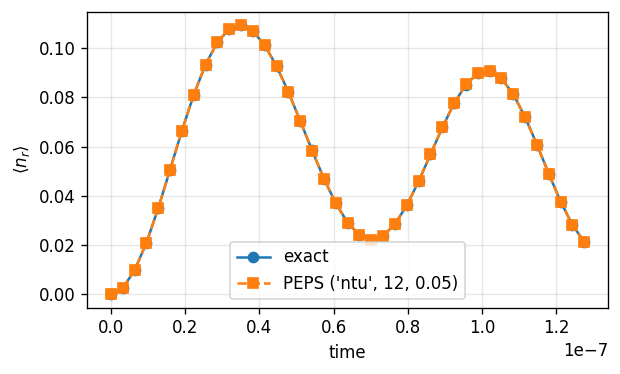

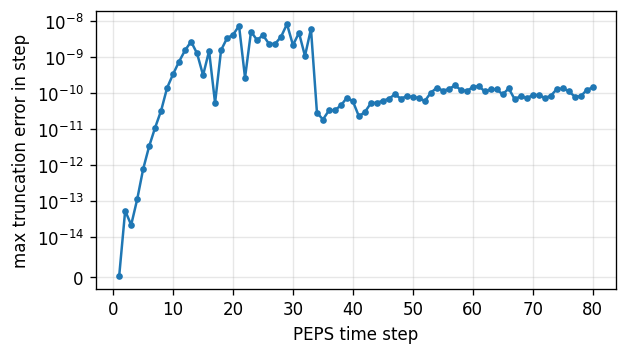

In [ ]:
ok_rows = [row for row in rows if row["status"] == "ok"]
if not ok_rows:
    raise RuntimeError("No PEPS convergence run completed. Check that yastn is installed and backend options are valid.")

best = min(ok_rows, key=lambda row: row["max_site_error"])
best_key = (best["env"], best["chi"], best["dt_factor"])
best_res = peps_results[best_key]
best_nr = np.asarray(best_res.metadata["obs"]["n_r"])
best_nmean = np.asarray(best_res.metadata["obs"]["n_mean"])

print("best PEPS row:")
print(best)

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(t_eval, exact_n_mean, "o-", label="exact")
ax.plot(best_res.times, best_nmean, "s--", label=f"PEPS {best_key}")
ax.set_xlabel("time")
ax.set_ylabel(r"$\langle n_r \rangle$")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

trunc = np.asarray(best_res.metadata.get("truncation_error", []), dtype=float)
if trunc.size:
    fig_t, ax_t = plt.subplots(figsize=(5.6, 3.0))
    ax_t.plot(np.arange(1, trunc.size + 1), trunc, ".-")
    ax_t.set_xlabel("PEPS time step")
    ax_t.set_ylabel("max truncation error in step")
    ax_t.set_yscale("symlog", linthresh=1e-14)
    ax_t.grid(alpha=0.3)
    plt.show()

## 5. 逐格点 Rydberg occupation color map

检查 PEPS 不只平均值对、空间分布也要对 exact。对 local addressing / 非均匀 protocol,这比平均值更关键。

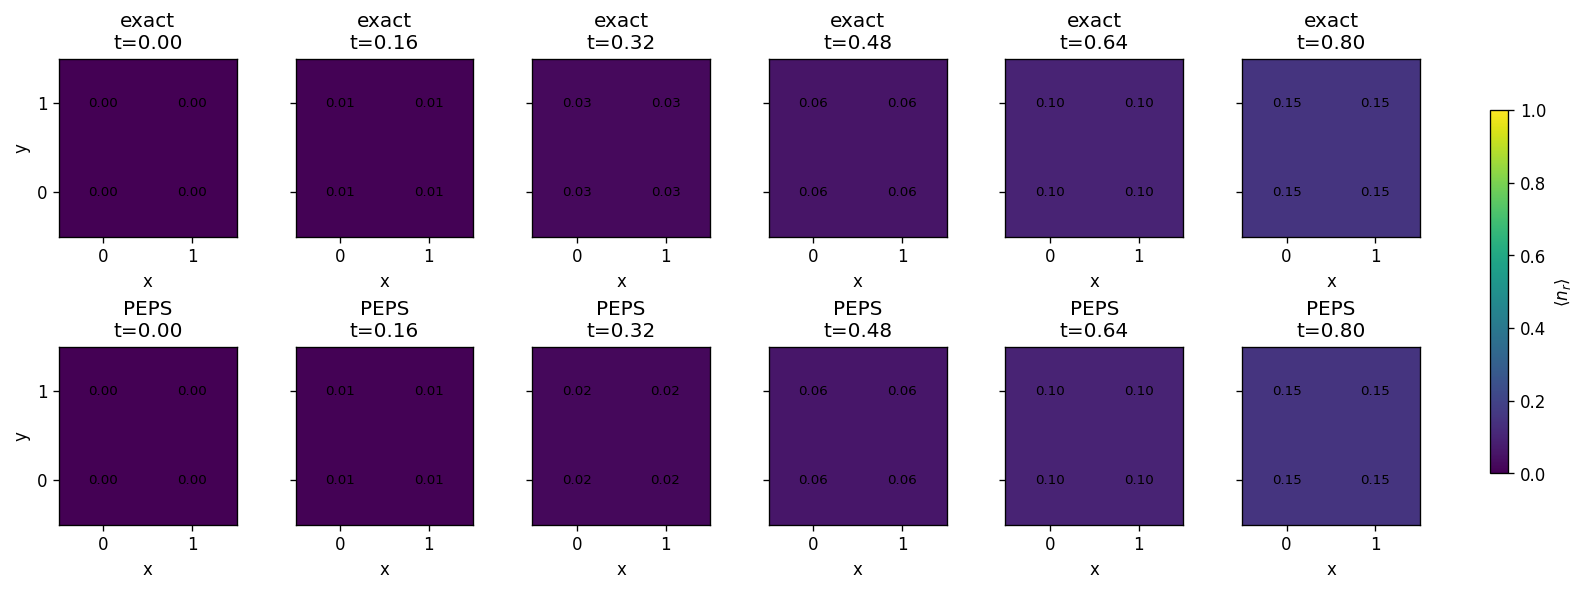

In [8]:
fig_h, axes_h = plt.subplots(2, len(t_eval), figsize=(2.25 * len(t_eval), 4.8), constrained_layout=True)

for row_idx, (label, occ_series) in enumerate([("exact", exact_nr), ("PEPS", best_nr)]):
    for ax_h, t, occ in zip(axes_h[row_idx], t_eval, occ_series):
        grid = occ.reshape(Lx, Ly)
        im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax_h.set_title(f"{label}\nt={t * 1e6:.3f} μs")
        ax_h.set_xticks(range(Lx))
        ax_h.set_yticks(range(Ly))
        if ax_h is axes_h[row_idx, 0]:
            ax_h.set_ylabel("y")
        else:
            ax_h.set_yticklabels([])
        ax_h.set_xlabel("x")
        for ix in range(Lx):
            for iy in range(Ly):
                val = grid[ix, iy]
                txt_color = "white" if val > 0.55 else "black"
                ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

fig_h.colorbar(im, ax=axes_h.ravel().tolist(), shrink=0.78, label=r"$\langle n_r \rangle$")
plt.show()

## 6. 用 CTM measurement 复查最佳参数

对最佳 `dt/chi/update_env` 改用 CTM measurement 重跑:CTM 与 BP 的 `n_r` 差异小 → observable contraction 不是主误差源;差异大 → 应先增大 measurement bond/environment,而非只增 PEPS `chi_max`。

CTM measurement runtime: 0.55 s
max |BP-CTM| per-site n_r: 0.0
max |CTM-exact| per-site n_r: 0.004669921548699607


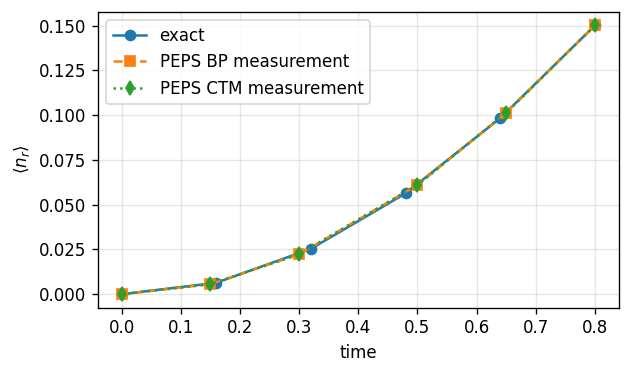

In [9]:
tic = time.perf_counter()
ctm_res = rg.simulate(
    system,
    [],
    initial_state,
    backend="peps",
    t_eval=t_eval,
    observables=["n_r", "n_mean"],
    backend_options={
        "chi_max": int(best["chi"]),
        "dt": float(best["dt_factor"]) / Omega_R,
        "svd_min": 1e-10,
        "update_environment": best["env"],
        "measurement_environment": "ctm",
        "initialization": "SVD",
        "max_iter": 30,
        "tol_iter": 1e-12,
        "use_cuda": False,
    },
)
ctm_time = time.perf_counter() - tic
ctm_nr = np.asarray(ctm_res.metadata["obs"]["n_r"])
ctm_nmean = np.asarray(ctm_res.metadata["obs"]["n_mean"])

print(f"CTM measurement runtime: {ctm_time:.2f} s")
print("max |BP-CTM| per-site n_r:", np.max(np.abs(best_nr - ctm_nr)))
print("max |CTM-exact| per-site n_r:", np.max(np.abs(ctm_nr - exact_nr)))

fig, ax = plt.subplots(figsize=(5.6, 3.2))
t_us = t_eval * 1e6
ax.plot(t_us, exact_n_mean, "o-", label="exact")
ax.plot(best_res.times * 1e6, best_nmean, "s--", label="PEPS BP measurement")
ax.plot(ctm_res.times * 1e6, ctm_nmean, "d:", label="PEPS CTM measurement")
ax.set_xlabel("time (μs)")
ax.set_ylabel(r"$\langle n_r \rangle$")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Part B — 2D square-lattice TFIM 临界场 $g_c$

`1r`→TFIM 映射 $J=V/4,\ g=2\Omega/V$;固定 $J=1$($V_{nn}=4$),$h_z=0$。
Part 1 在 $4\times4$ 上对照 exact / MPS-DMRG / PEPS(YASTN)基态能量;Part 2 用关联比 $R(g)$ 交叉读 $g_c$。

In [ ]:
import time
from dataclasses import replace
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

import ryd_gate as rg
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register
from ryd_gate.core.operators import (
    materialize_sparse_operator, WeightedProjectorSumSpec, is_operator_spec,
)
from ryd_gate.protocols.lattice_dynamics import TFIMQuenchProtocol, tfim_to_rydberg_controls
from ryd_gate.backends.tn_common.lattice_spec import create_tn_lattice_spec
from ryd_gate.backends.tn_common.protocol_context import TNProtocolContext, pin_deltas_from_params
from ryd_gate.backends.tn_common.compiler import TNEvolutionIR
from ryd_gate.backends.tenpy_mps.backends import TenpyDMRGBackend
from ryd_gate.backends.peps2d import YASTNPEPSBackend

plt.rcParams.update({"figure.dpi": 120})
J, V_NN, G_C_REF = 1.0, 4.0, 3.04438
print("setup done; QMC reference g_c =", G_C_REF)

## Part 1 — $4\times4$ ground-state energy: exact vs MPS vs PEPS

All three solve the *same* nearest-neighbour TFIM at field $g$ on a $4\times4$ open
cluster (with $h_z=0$ pins) and should return the same ground-state energy.

In [ ]:
G1 = np.round(np.linspace(2.6, 3.5, 6), 4)
E_exact, E_mps, E_peps = [], [], []
for g in G1:
    t0 = time.perf_counter()

    # --- exact: assemble the full 1r Hamiltonian and take the Lanczos ground state ---
    geom = Register.rectangle(4, 4, spacing_um=1.0)
    proto = TFIMQuenchProtocol(hx=g * J, hz=0.0, t_gate=1.0)
    system = rg.RydbergSystem.from_lattice(
        geom, "1r", interaction=InteractionSpec(C6=V_NN, mode="nn"), protocol=proto)
    irh = rg.compile_hamiltonian_ir(system, system.unpack_params([]))
    H = None
    for term in list(irh.static_terms) + list(irh.drive_terms):
        c = term.coefficient(0) if callable(term.coefficient) else term.coefficient
        op = materialize_sparse_operator(term.operator, system.basis) if is_operator_spec(term.operator) else term.operator
        contrib = c * op
        if getattr(term, "add_hermitian_conjugate", False):
            contrib = contrib + np.conj(c) * op.conj().T
        H = contrib if H is None else H + contrib
    Eex = float(eigsh(H.tocsc(), k=1, which="SA")[0][0])

    # --- MPS (DMRG) ---
    spec = create_tn_lattice_spec(Lx=4, Ly=4, V_nn=V_NN, Omega=1.0, bc="open",
                                  level_structure="1r", interaction_mode="nn")
    ctrl = tfim_to_rydberg_controls(TNProtocolContext(spec), hx=g * J, hz=0.0)
    pin = pin_deltas_from_params({"pin_deltas": ctrl.pin_deltas}, spec.N)
    res_m = TenpyDMRGBackend(chi_max=128, n_sweeps=14, svd_min=1e-10).find_ground_state(
        replace(spec, Omega=ctrl.Omega), ctrl.Delta, pin_deltas=pin, initial_state="af1")
    Em = float(res_m.metadata["energy"])

    # --- PEPS (YASTN imaginary-time NTU ground state) ---
    params = proto.unpack_params([], TNProtocolContext(spec))
    ir = TNEvolutionIR(spec=spec, protocol=proto, params=params, metadata={})
    res_p = YASTNPEPSBackend(chi_max=8, dt=0.05).find_ground_state(
        ir, dtau_schedule=((0.1, 40), (0.03, 40), (0.02, 50)), initial_state="af1")
    Ep = float(res_p.metadata["energy"])

    E_exact.append(Eex); E_mps.append(Em); E_peps.append(Ep)
    print(f"g={g:.4f}  E_exact={Eex:.4f}  E_mps={Em:.4f}  E_peps={Ep:.4f}  "
          f"d(mps)={Em - Eex:+.1e}  d(peps)={Ep - Eex:+.1e}  t={time.perf_counter() - t0:.0f}s",
          flush=True)

E_exact, E_mps, E_peps = np.array(E_exact), np.array(E_mps), np.array(E_peps)
print(f"\nmax |E_mps  - E_exact| = {np.max(np.abs(E_mps - E_exact)):.2e}")
print(f"max |E_peps - E_exact| = {np.max(np.abs(E_peps - E_exact)):.2e}")

In [ ]:
plt.figure(figsize=(6.2, 4.2))
plt.plot(G1, E_exact, "k-o", label="exact (eigsh)")
plt.plot(G1, E_mps, "C0-s", label="MPS (DMRG, $\\chi$=128)")
plt.plot(G1, E_peps, "C1-^", label="PEPS (YASTN, D=8)")
plt.axvline(G_C_REF, color="gray", ls="--", lw=1, label=f"$g_c$={G_C_REF}")
plt.xlabel(r"$g = 2\Omega/V$"); plt.ylabel("ground-state energy $E$")
plt.title(r"$4\times4$ TFIM ground-state energy")
plt.legend(); plt.tight_layout(); plt.show()

## Part 2 — correlation ratio $R(g)$ and $g_c$ from the crossing

The three methods agree at $4\times4$, so we now scale up the correlation ratio
$R=1-S(\mathbf Q+\delta\mathbf q)/S(\mathbf Q)$ ($\mathbf Q=(\pi,\pi)$,
$\delta\mathbf q=(2\pi/L,0)$). $R$ is RG-invariant, so $R(g)$ curves for different
$L$ cross at $g_c$. We run MPS at $L=4,5,6$; exact anchors $L=4$. (The YASTN PEPS path does not
expose the full $\langle ZZ\rangle$ correlation matrix this scan needs, so the
correlation ratio is computed from MPS. Open clusters bias the crossing
slightly above the bulk $g_c$.)

In [ ]:
G2 = np.array([2.8, 3.0, 3.04438, 3.15, 3.3])
MPS_CHI = {4: 128, 5: 200, 6: 300}
R_mps = {4: [], 5: [], 6: []}
R_exact = {4: []}

for L in (4, 5, 6):
    spec = create_tn_lattice_spec(Lx=L, Ly=L, V_nn=V_NN, Omega=1.0, bc="open",
                                  level_structure="1r", interaction_mode="nn")
    N = spec.N
    coords = spec.coords                          # (N, 2) in 2D site order
    idx = spec.snake_to_2d                          # snake(1D) -> 2D site
    Q = np.array([np.pi, np.pi]); dq = np.array([2 * np.pi / L, 0.0])
    phQ = np.exp(1j * (coords @ Q)); phQd = np.exp(1j * (coords @ (Q + dq)))
    for g in G2:
        t0 = time.perf_counter()
        # --- MPS correlation matrix <Z_i Z_j> = 4<Sz_i Sz_j> ---
        ctrl = tfim_to_rydberg_controls(TNProtocolContext(spec), hx=g * J, hz=0.0)
        pin = pin_deltas_from_params({"pin_deltas": ctrl.pin_deltas}, N)
        res_m = TenpyDMRGBackend(chi_max=MPS_CHI[L], n_sweeps=14, svd_min=1e-10).find_ground_state(
            replace(spec, Omega=ctrl.Omega), ctrl.Delta, pin_deltas=pin, initial_state="af1")
        Csnake = 4.0 * np.asarray(res_m.psi_final.correlation_function("Sz", "Sz"))
        Cm = np.empty_like(Csnake); Cm[np.ix_(idx, idx)] = Csnake     # -> 2D site order
        sQ = float(np.real(np.conj(phQ) @ Cm @ phQ) / N)
        sQd = float(np.real(np.conj(phQd) @ Cm @ phQd) / N)
        R_mps[L].append(1.0 - sQd / sQ if abs(sQ) > 1e-12 else np.nan)

        # --- exact correlation matrix (anchor at L=4 only) ---
        if L == 4:
            geom = Register.rectangle(4, 4, spacing_um=1.0)
            proto = TFIMQuenchProtocol(hx=g * J, hz=0.0, t_gate=1.0)
            system = rg.RydbergSystem.from_lattice(
                geom, "1r", interaction=InteractionSpec(C6=V_NN, mode="nn"), protocol=proto)
            irh = rg.compile_hamiltonian_ir(system, system.unpack_params([]))
            H = None
            for term in list(irh.static_terms) + list(irh.drive_terms):
                c = term.coefficient(0) if callable(term.coefficient) else term.coefficient
                op = materialize_sparse_operator(term.operator, system.basis) if is_operator_spec(term.operator) else term.operator
                contrib = c * op
                if getattr(term, "add_hermitian_conjugate", False):
                    contrib = contrib + np.conj(c) * op.conj().T
                H = contrib if H is None else H + contrib
            psi0 = eigsh(H.tocsc(), k=1, which="SA")[1][:, 0]
            Zpsi = np.empty((N, psi0.size), dtype=complex)            # Z_i |psi>, Z_i = 2 n_r,i - I
            for i in range(N):
                ei = np.zeros(N); ei[i] = 1.0
                Pri = materialize_sparse_operator(WeightedProjectorSumSpec("r", tuple(ei)), system.basis)
                Zpsi[i] = (2.0 * Pri) @ psi0 - psi0
            Cx = np.real(Zpsi.conj() @ Zpsi.T)                        # <Z_i Z_j>
            sQ = float(np.real(np.conj(phQ) @ Cx @ phQ) / N)
            sQd = float(np.real(np.conj(phQd) @ Cx @ phQd) / N)
            R_exact[4].append(1.0 - sQd / sQ if abs(sQ) > 1e-12 else np.nan)
        print(f"  [L={L}] g={g:.4f}  t={time.perf_counter() - t0:.0f}s", flush=True)

In [ ]:
plt.figure(figsize=(7.2, 4.6))
for L in (4, 5, 6):
    plt.plot(G2, R_mps[L], "-o", label=f"MPS L={L}")
plt.plot(G2, R_exact[4], "k:^", lw=1.5, label="exact L=4")
plt.axvline(G_C_REF, color="gray", ls="--", lw=1, label=f"$g_c$={G_C_REF}")
plt.xlabel(r"$g = 2\Omega/V$"); plt.ylabel(r"$R = 1 - S(Q+\delta q)/S(Q)$")
plt.title("correlation ratio (curves cross at $g_c$)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

# g_c from the crossing of two R(g) curves (inline linear interpolation)
gg = np.linspace(G2.min(), G2.max(), 800)
d_mps = np.interp(gg, G2, R_mps[6]) - np.interp(gg, G2, R_mps[5])
sc = np.where(np.sign(d_mps[:-1]) != np.sign(d_mps[1:]))[0]
gc_mps = float(gg[sc[0]] - d_mps[sc[0]] * (gg[sc[0] + 1] - gg[sc[0]]) / (d_mps[sc[0] + 1] - d_mps[sc[0]])) if sc.size else float("nan")
print(f"g_c  (MPS  L=5x6 crossing) = {gc_mps:.4f}")
print(f"g_c  (QMC reference)       = {G_C_REF}")

## Part C — quench error budget 扫描

`a(间距) / Delta_e(中间态失谐) / v(扫频速度)` 三参数最小化绝热 quench 误差:1r 相干动力学 + `our` 常数解析退相干。
完整 headless 扫描见 `scripts/run_peps_10x10.py` 的模式。

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

import ryd_gate as rg
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register

## `our` 三能级常数(可改)

取自 `src/ryd_gate/core/physical_models.py:128-146`(`param_set="our"`, 70S, `rb87_7`),
已用 `system.meta(...)` 核对。**要改实验参数就改这里**。

In [ ]:
# ====== 'our' 参数集常数 (rad/s 除非另注; 见 physical_models.py:128-146) ======
OMEGA_420  = 2 * np.pi * 491e6    # 420 nm 单光子 Rabi (|g>-|e>)
OMEGA_1013 = 2 * np.pi * 185e6    # 1013 nm 单光子 Rabi (|e>-|r>)
GAMMA_R    = 6598.0               # Rydberg 衰减率 (tau_r = 151.5 us)
GAMMA_E    = 9.033e6             # 中间态衰减率 (tau_e = 110.7 ns)
C6         = 2 * np.pi * 874e9    # rad/s * um^6, Rb 70S van der Waals
DELTA_E_0  = 2 * np.pi * 9.1e9    # 默认中间态失谐 (扫描时被覆盖)

def omega_eff(delta_e):
    # 两光子有效 Rabi: Omega_eff = Omega_420 * Omega_1013 / (2 * Delta_e)
    return OMEGA_420 * OMEGA_1013 / (2.0 * delta_e)

def scatter_rate(delta_e):
    # 中间态光子散射率 (每原子, 满驱动): R_sc ~ Gamma_e * (Omega_420 / 2 Delta_e)^2
    # = 中间态布居 (Omega_420/2Delta_e)^2 乘以 Gamma_e。可与 yuhao/雨神 再核对(含 1013 腿 / AC Stark?)
    return GAMMA_E * (OMEGA_420 / (2.0 * delta_e)) ** 2

print(f"Omega_eff(De=9.1GHz) = 2pi x {omega_eff(DELTA_E_0)/2/np.pi/1e6:.2f} MHz")
print(f"R_sc(De=9.1GHz)      = {scatter_rate(DELTA_E_0):.3e} /s  (tau_e={1/GAMMA_E*1e9:.1f} ns)")

## 相干 forward model(`"1r"` exact)+ error budget

对每个 `(a, Delta_e, v)`:在 `"1r"` 两能级 + 最近邻 VdW 上跑往返 detuning sweep,取 `P_r(t)`。

**误差定义(可改)**

- `eps_coh` = 往返结束后的残余平均激发 `<n_r>(T)`(理想绝热往返应回基态 → 残余=非绝热误差)。
  若改成单向制备某有序态,换成 `1 - |<target|psi(T)>|^2`。
- `eps_SE` = `Gamma_r * integral P_r dt`
- `eps_sc` = `R_sc(Delta_e) * integral env(t) dt`(散射只在激光开时发生)

> 待与 yuhao 定:detuning 扫描幅度 `d_amp` 与 `t_sweep` 现为占位值,应随 `Omega_eff` 标度
> (Delta_e=1GHz 时 Omega_eff~45 MHz 远大于占位的 +-10 MHz,会让相干部分失真)。

In [ ]:
def forward(Lx, Ly, a_um, delta_e, v, n_eval=25, n_steps=120):
    # '1r' 相干往返 sweep -> 每原子 error budget dict
    Oeff = omega_eff(delta_e)
    t_sweep = 1.5e-6 / v                 # v = 振荡速度倍数 (0.7-1.5)
    d_amp = 2 * np.pi * 10e6             # TODO(yuhao): 应随 Oeff 标度

    def omega_half(t):
        s = np.clip(t / t_sweep, 0, 1)
        ss = lambda u: (lambda u: 10*u**3 - 15*u**4 + 6*u**5)(np.clip(u, 0, 1))
        return 0.5 * Oeff * (ss(s/0.09) if s < 0.09 else (ss((1-s)/0.09) if s > 0.91 else 1.0))

    def delta(t):
        s = np.clip(t / t_sweep, 0, 1)
        return -d_amp * np.cos(2 * np.pi * s)

    geom = Register.rectangle(Lx, Ly, spacing_um=a_um)
    proto = rg.SweepProtocol(t_gate=t_sweep, omega_half_fn=omega_half,
                             delta_fn=delta, n_steps=n_steps)
    sysm = rg.RydbergSystem.from_lattice(
        geom, "1r", interaction=InteractionSpec(C6=C6, mode="nn"), protocol=proto)
    t_eval = np.linspace(0, t_sweep, n_eval)
    res = rg.simulate(sysm, [], "all_ground", backend="exact_dense", t_eval=t_eval)
    N = sysm.N
    pr = np.array([sysm.expectation("sum_nr", psi) / N for psi in res.states])
    env_t = np.clip([omega_half(t) / (0.5 * Oeff) for t in t_eval], 0, 1)

    eps_coh = float(pr[-1])
    eps_se = GAMMA_R * np.trapz(pr, t_eval)
    eps_sc = scatter_rate(delta_e) * np.trapz(env_t, t_eval)
    return dict(Lx=Lx, Ly=Ly, a_um=a_um, delta_e=delta_e, v=v,
                Oeff_MHz=Oeff/2/np.pi/1e6, t_sweep_us=t_sweep*1e6, pr=pr, t_eval=t_eval,
                eps_coh=eps_coh, eps_se=eps_se, eps_sc=eps_sc,
                eps_total=eps_coh + eps_se + eps_sc)

## 单点 + 尺寸收敛(2x2 / 3x3 / 4x4)

先看基准点,再看 per-atom error 随尺寸是否收敛(决定代理系统多大够用)。`4x4` 是 `2^16=65536`,exact 上约几分钟。

In [ ]:
print(f"{'size':>5}  {'Oeff':>8}  {'eps_coh':>9}  {'eps_SE':>9}  {'eps_sc':>9}  {'TOTAL':>9}")
for Lx, Ly in [(2, 2), (3, 3), (4, 4)]:
    r = forward(Lx, Ly, a_um=7.0, delta_e=DELTA_E_0, v=1.0)
    print(f"{Lx}x{Ly:<2}  {r['Oeff_MHz']:6.2f}MHz  {r['eps_coh']:9.3e}  "
          f"{r['eps_se']:9.3e}  {r['eps_sc']:9.3e}  {r['eps_total']:9.3e}")

## Delta_e 扫描(看 散射 vs 速度 的折中)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
des = np.linspace(1.0, 3.0, 9)
for key, lbl in [("eps_coh", "coherent"), ("eps_se", "spont. emiss."),
                 ("eps_sc", "mid scatter"), ("eps_total", "total")]:
    ys = [forward(3, 3, 7.0, 2*np.pi*d*1e9, 1.0)[key] for d in des]
    ax.plot(des, ys, marker="o", label=lbl)
ax.set_xlabel("Delta_e (GHz)"); ax.set_ylabel("error per atom")
ax.set_yscale("log"); ax.legend(); ax.set_title("3x3, a=7um, v=1")
plt.show()

## 三参数网格扫描 + 服务器部署

扫描骨架。**真正跑**时按 `scripts/optimize_ar_cz.py` 约定:搜索循环放 `scripts/`(不是 notebook),
headless 起(`setsid nohup ... > log 2>&1`),结果 checkpoint 到 JSON/npz,支持 `--resume`。
建议先 grid 粗扫看地形,再用 `scipy.optimize.minimize`(Nelder-Mead) 精修。

In [ ]:
def grid_sweep(a_list, de_list_GHz, v_list, Lx=3, Ly=3):
    rows = []
    for a in a_list:
        for d in de_list_GHz:
            for v in v_list:
                r = forward(Lx, Ly, a, 2*np.pi*d*1e9, v)
                rows.append((a, d, v, r["eps_coh"], r["eps_se"], r["eps_sc"], r["eps_total"]))
    return np.array(rows)

# 小演示网格 (真正扫描放 scripts/ 里 headless 跑)
demo = grid_sweep([6.0, 8.0], [2.0, 3.0], [1.0])
print("cols: a, De(GHz), v, coh, SE, sc, total")
print(np.round(demo, 4))
print("best:", demo[np.argmin(demo[:, -1])])

## 10×10 验证 + 待办

- 最优点用 `10×10` PEPS(chi=8,见 `scripts/run_peps_10x10.py`)复算相干部分,确认有限尺寸/边界没推翻代理结论。
- **待与 yuhao 定**:(1) `d_amp` 与 `t_sweep` 如何随 `Omega_eff` 标度;(2) 散射模型是否含 1013 腿 / AC Stark;(3) `eps_coh` 用往返残余还是对目标态保真;(4) 原子丢失单独计还是 ≈ eps_SE + eps_sc。
- **Track B(算法梳理)** 并行:在 `04_quench_and_state_prep.ipynb`(Part A)的 4×4 上做 SU / NTU / MPS 精度-时间对照,写一页"算法 × 用途(演化 vs 基态)"表。